# Exploratory Data Analysis - Train Narratives Dataset
This notebook explores the text business descriptions in `train_narratives.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## Loading the Dataset


In [2]:
df = pd.read_csv('../data/train_narratives.csv')
print(f'Dataset shape: {df.shape}')
df.head()


Dataset shape: (1000, 2)


,company_id,business_description
0,1,Aster Holdings #0001 operates in the retail se...
1,2,BluePeak Solutions #0002 operates in the hospi...
2,3,Crestline Partners #0003 operates in the real ...
3,4,Dune Finance #0004 operates in the logistics s...
4,5,Evergreen Holdings #0005 operates in the logis...


## Data Quality & Missing Values


In [3]:
df.info()
print('\nMissing values per column:')
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   company_id            1000 non-null   int64
 1   business_description  1000 non-null   str  
dtypes: int64(1), str(1)
memory usage: 271.2 KB

Missing values per column:
company_id              0
business_description    0
dtype: int64


## Duplicate Check


In [4]:
print(f'Duplicate company_id count: {df["company_id"].duplicated().sum()}')


Duplicate company_id count: 0


## Text Length Analysis


In [5]:
df['char_count'] = df['business_description'].fillna('').apply(len)
df['word_count'] = df['business_description'].fillna('').apply(lambda x: len(x.split()))
df[['char_count', 'word_count']].describe()


,char_count,word_count
count,1000.000000,1000.000000
mean,261.596000,34.760000
std,47.456389,6.651966
min,172.000000,23.000000
25%,231.000000,30.000000
50%,262.000000,35.000000
75%,292.000000,40.000000
max,365.000000,51.000000


## Text Length Distributions


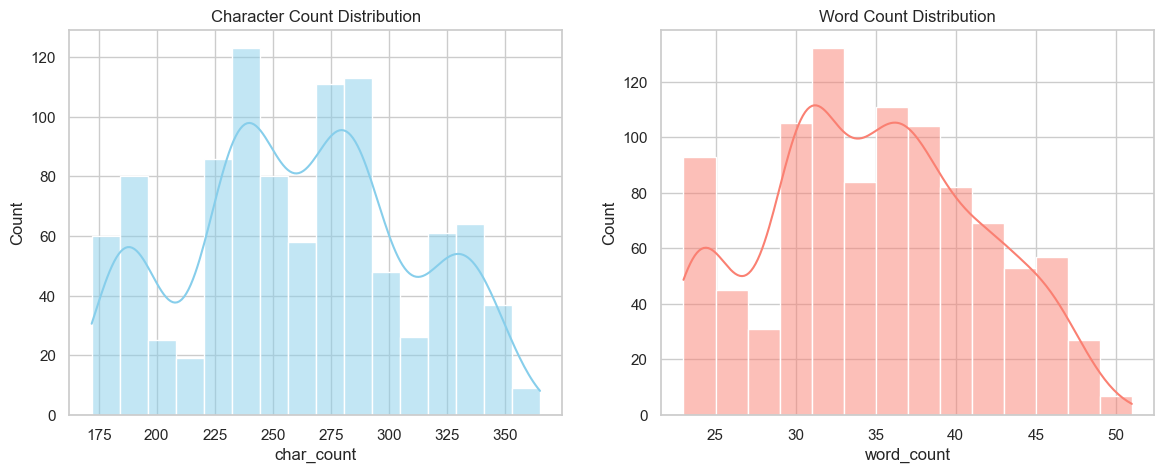

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['char_count'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Character Count Distribution')
sns.histplot(df['word_count'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Word Count Distribution')
plt.show()


## Presence of Key Qualitative/Risk Risk Signals
We scan the narratives for common risk/opportunity phrases highlighted in the project description.


In [7]:
risk_phrases = [
    'declining revenue', 'high customer concentration', 'regulatory uncertainty',
    'weak liquidity', 'strong market position', 'short operating history',
    'recurring subscription revenue', 'default', 'bankruptcy'
]
for phrase in risk_phrases:
    count = df['business_description'].str.contains(phrase, case=False, na=False).sum()
    print(f"Contains '{phrase}': {count} narratives ({count/len(df)*100:.2f}%)")


Contains 'declining revenue': 192 narratives (19.20%)
Contains 'high customer concentration': 201 narratives (20.10%)
Contains 'regulatory uncertainty': 202 narratives (20.20%)
Contains 'weak liquidity': 189 narratives (18.90%)
Contains 'strong market position': 77 narratives (7.70%)
Contains 'short operating history': 208 narratives (20.80%)
Contains 'recurring subscription revenue': 82 narratives (8.20%)
Contains 'default': 0 narratives (0.00%)
Contains 'bankruptcy': 0 narratives (0.00%)


## Narrative Examples


In [8]:
pd.set_option('display.max_colwidth', None)
df[['company_id', 'business_description']].head(5)


,company_id,business_description
0,1,Aster Holdings #0001 operates in the retail sector. The business faces regulatory uncertainty. The business faces legacy debt burden. Management focuses on operational efficiency and cross-selling to preserve margins.
1,2,BluePeak Solutions #0002 operates in the hospitality sector. The business faces dependence on a few key accounts. Management focuses on operational efficiency and cross-selling to preserve margins.
2,3,Crestline Partners #0003 operates in the real estate sector. The business faces weak liquidity position. The business faces regulatory uncertainty. The business faces margin compression. The company benefits from diversified customer base. Management focuses on operational efficiency and cross-selling to preserve margins.
3,4,Dune Finance #0004 operates in the logistics sector. The business faces regulatory uncertainty. The business faces margin compression. Management focuses on operational efficiency and cross-selling to preserve margins.
4,5,Evergreen Holdings #0005 operates in the logistics sector. The business faces exposed to volatile commodity prices. Management focuses on operational efficiency and cross-selling to preserve margins.
